In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q librosa soundfile openai-whisper joblib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 34.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.5 MB/s eta 0:00:00


In [3]:
import os
import json
import cv2
import math
import joblib
import librosa
import random
import warnings
import subprocess
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [
    CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR,
    MODEL_DIR, GRAPH_DIR, REPORT_DIR, PRED_DIR,
    EXPLAIN_DIR, UNCERTAIN_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [ ]:
metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

records = []

for filename, info in metadata.items():
    video_path = os.path.join(RAW_DIR, filename)

    if os.path.exists(video_path):
        label = info["label"]  
        target = 1 if label == "FAKE" else 0

        records.append({
            "filename": filename,
            "video_path": video_path,
            "label": label,
            "target": target,
            "original": info.get("original", None)
        })

df = pd.DataFrame(records)
df.to_csv(os.path.join(CSV_DIR, "dfdc_metadata.csv"), index=False)

print("Total videos found:", len(df))
print(df["label"].value_counts())
df.head()

Total videos found: 1334
label
FAKE    1248
REAL      86
Name: count, dtype: int64


,filename,video_path,label,target,original
0,owxbbpjpch.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,1,wynotylpnm.mp4
1,vpmyeepbep.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,REAL,0,None
2,fzvpbrzssi.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,REAL,0,None
3,htorvhbcae.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,1,wclvkepakb.mp4
4,fckxaqjbxk.mp4,/content/drive/MyDrive/Deepfake_Project/data/r...,FAKE,1,vpmyeepbep.mp4


In [ ]:
SAMPLE_PER_CLASS = 80  

df_sample = (
    df.groupby("target", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

train_df, test_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample["target"]
)

train_df.to_csv(os.path.join(CSV_DIR, "train.csv"), index=False)
test_df.to_csv(os.path.join(CSV_DIR, "test.csv"), index=False)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Train labels:")
print(train_df["label"].value_counts())
print("Test labels:")
print(test_df["label"].value_counts())

Train size: 128
Test size: 32
Train labels:
label
REAL    64
FAKE    64
Name: count, dtype: int64
Test labels:
label
FAKE    16
REAL    16
Name: count, dtype: int64


In [38]:
NUM_FRAMES = 10

def extract_frames(video_path, output_folder, num_frames=10):
    os.makedirs(output_folder, exist_ok=True)

    existing_frames = list(Path(output_folder).glob("*.jpg"))
    if len(existing_frames) >= num_frames:
        return True

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return False

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return False

    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    saved = 0

    for idx, frame_no in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(output_folder, f"frame_{idx:03d}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()
    return saved > 0


all_df = pd.concat([train_df, test_df]).reset_index(drop=True)

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    video_id = Path(row["filename"]).stem
    output_folder = os.path.join(FRAMES_DIR, video_id)
    extract_frames(row["video_path"], output_folder, NUM_FRAMES)

print("Frame extraction completed.")

100%|██████████| 160/160 [00:00<00:00, 442.55it/s]

Frame extraction completed.


In [39]:
def extract_audio(video_path, audio_path):
    if os.path.exists(audio_path):
        return True

    command = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        audio_path
    ]

    try:
        subprocess.run(
            command,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            timeout=60
        )
        return os.path.exists(audio_path)
    except:
        return False


for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    video_id = Path(row["filename"]).stem
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")
    extract_audio(row["video_path"], audio_path)

print("Audio extraction completed.")

100%|██████████| 160/160 [00:00<00:00, 1784.27it/s]

Audio extraction completed.


In [40]:
visual_feature_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

def extract_visual_feature(video_id):
    frame_folder = os.path.join(FRAMES_DIR, video_id)
    frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

    if len(frame_paths) == 0:
        return np.zeros(1280)

    imgs = []

    for frame_path in frame_paths:
        img = image.load_img(frame_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        imgs.append(img_array)

    imgs = np.array(imgs)
    imgs = preprocess_input(imgs)

    features = visual_feature_model.predict(imgs, verbose=0)
    video_feature = np.mean(features, axis=0)

    return video_feature


visual_records = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    feature = extract_visual_feature(video_id)

    record = {"filename": filename}
    for i, value in enumerate(feature):
        record[f"v_{i}"] = value

    visual_records.append(record)

visual_df = pd.DataFrame(visual_records)
visual_df.to_csv(os.path.join(CSV_DIR, "visual_features.csv"), index=False)

print("Visual features saved.")
visual_df.head()

100%|██████████| 160/160 [02:20<00:00,  1.14it/s]


Visual features saved.


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,ddtbarpcgo.mp4,0.056554,0.025291,0.994786,0.609277,0.814384,0.065653,0.253342,0.038582,0.170496,...,0.041556,1.050260,0.366795,1.152847,0.275217,0.371571,0.344613,1.151582,0.015143,0.024055
1,syxobtuucp.mp4,0.069535,0.044261,1.120283,0.528944,0.841009,0.056741,0.309276,0.114287,0.270597,...,0.035813,1.086458,0.312757,1.061816,0.213346,0.359685,0.426661,1.218248,0.016477,0.021587
2,rnpefxwptv.mp4,0.195628,0.010402,0.014313,0.511814,0.263171,0.773110,0.728687,0.215997,0.106443,...,0.166937,0.444224,0.052120,0.585693,0.131410,0.002428,0.800236,0.701693,0.142030,1.903183
3,xcruhaccxc.mp4,0.003278,0.050007,0.233104,1.358269,0.656057,0.715045,0.335984,0.452931,0.299853,...,0.774010,0.807078,0.384868,0.196255,0.072295,0.165259,0.113436,1.713391,0.482835,0.491861
4,jvtjxreizj.mp4,0.000000,0.000000,0.038383,0.368220,0.712629,1.141198,0.583322,0.065142,0.019467,...,0.012855,0.006219,0.539931,1.070719,0.490444,0.005333,0.005103,0.131395,0.005835,0.471701


In [41]:
def extract_audio_feature(video_id, n_mfcc=40):
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")

    if not os.path.exists(audio_path):
        return np.zeros(n_mfcc * 6)

    try:
        y, sr = librosa.load(audio_path, sr=16000)

        if len(y) == 0:
            return np.zeros(n_mfcc * 6)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        combined = np.vstack([mfcc, delta, delta2])

        mean_features = np.mean(combined, axis=1)
        std_features = np.std(combined, axis=1)

        final_audio_feature = np.concatenate([mean_features, std_features])
        return final_audio_feature

    except:
        return np.zeros(n_mfcc * 6)


audio_records = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    feature = extract_audio_feature(video_id)

    record = {"filename": filename}
    for i, value in enumerate(feature):
        record[f"a_{i}"] = value

    audio_records.append(record)

audio_df = pd.DataFrame(audio_records)
audio_df.to_csv(os.path.join(CSV_DIR, "audio_features.csv"), index=False)

print("Audio features saved.")
audio_df.head()

100%|██████████| 160/160 [00:04<00:00, 35.47it/s]


Audio features saved.


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,ddtbarpcgo.mp4,-428.645111,91.335808,-4.213846,14.454275,-12.636438,-3.421792,-9.671415,-3.723779,-5.397727,...,0.511774,0.669652,0.771352,0.906991,0.937824,0.919178,0.985267,1.117459,1.117663,0.938096
1,syxobtuucp.mp4,-438.742523,75.032623,7.246225,20.522755,-7.543080,-1.232122,-12.938012,-4.350680,-8.260976,...,0.629185,0.755014,0.761925,0.651810,0.869977,1.013530,0.933492,1.068106,0.963154,0.810464
2,rnpefxwptv.mp4,-305.519836,89.361786,-2.704516,11.468946,-5.403182,4.333642,-11.691155,-12.594668,-9.610823,...,0.485965,0.449502,0.437206,0.447647,0.444741,0.463272,0.475687,0.508356,0.405955,0.465901
3,xcruhaccxc.mp4,-442.120422,78.016075,14.903191,27.243885,-1.790590,-4.440570,-8.863456,-5.128759,-16.919720,...,0.641588,0.652792,0.664840,0.769273,0.948641,1.085567,1.077956,0.780514,0.852449,1.059313
4,jvtjxreizj.mp4,-276.327789,99.367249,-21.568441,14.879811,-22.316044,7.086238,-10.989186,-7.660557,-5.686695,...,0.978620,0.869967,0.788119,0.863998,0.946503,1.130210,1.035000,0.959097,0.760916,0.927874


In [42]:
import whisper

whisper_model = whisper.load_model("tiny")

def transcribe_audio(video_id):
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")
    text_path = os.path.join(TEXT_DIR, f"{video_id}.txt")

    if os.path.exists(text_path):
        with open(text_path, "r", encoding="utf-8") as f:
            return f.read()

    if not os.path.exists(audio_path):
        transcript = ""
    else:
        try:
            result = whisper_model.transcribe(audio_path)
            transcript = result["text"]
        except:
            transcript = ""

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript


text_records = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    transcript = transcribe_audio(video_id)

    text_records.append({
        "filename": filename,
        "transcript": transcript
    })

text_df = pd.DataFrame(text_records)
text_df.to_csv(os.path.join(CSV_DIR, "text_transcripts.csv"), index=False)

print("Text extraction completed.")
text_df.head()

100%|██████████| 160/160 [00:00<00:00, 235.27it/s]

Text extraction completed.


,filename,transcript
0,ddtbarpcgo.mp4,I don't even know what half of them are anymo...
1,syxobtuucp.mp4,We're not going through our photos and often ...
2,rnpefxwptv.mp4,"the news and the portuless, the world tax, et..."
3,xcruhaccxc.mp4,"as a single mom, not something that I absolut..."
4,jvtjxreizj.mp4,and ships had been dumping them. Merchant shi...


In [43]:
train_df = pd.read_csv(os.path.join(CSV_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(CSV_DIR, "test.csv"))

visual_df = pd.read_csv(os.path.join(CSV_DIR, "visual_features.csv")).set_index("filename")
audio_df = pd.read_csv(os.path.join(CSV_DIR, "audio_features.csv")).set_index("filename")
text_df = pd.read_csv(os.path.join(CSV_DIR, "text_transcripts.csv")).set_index("filename")

visual_cols = [col for col in visual_df.columns if col.startswith("v_")]
audio_cols = [col for col in audio_df.columns if col.startswith("a_")]

def get_text(filename):
    try:
        text = text_df.loc[filename, "transcript"]
        if pd.isna(text):
            return ""
        return str(text)
    except:
        return ""

train_files = train_df["filename"].tolist()
test_files = test_df["filename"].tolist()

X_visual_train = visual_df.reindex(train_files).fillna(0)[visual_cols].values
X_visual_test = visual_df.reindex(test_files).fillna(0)[visual_cols].values

X_audio_train = audio_df.reindex(train_files).fillna(0)[audio_cols].values
X_audio_test = audio_df.reindex(test_files).fillna(0)[audio_cols].values

train_texts = [get_text(f) for f in train_files]
test_texts = [get_text(f) for f in test_files]

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(train_texts).toarray()
X_text_test = tfidf.transform(test_texts).toarray()

X_train = np.hstack([X_visual_train, X_audio_train, X_text_train])
X_test = np.hstack([X_visual_test, X_audio_test, X_text_test])

y_train = train_df["target"].values
y_test = test_df["target"].values

feature_names = (
    visual_cols +
    audio_cols +
    [f"text_{word}" for word in tfidf.get_feature_names_out()]
)

print("Fused train shape:", X_train.shape)
print("Fused test shape:", X_test.shape)

Fused train shape: (128, 2020)
Fused test shape: (32, 2020)


In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(tfidf, os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))

print("Feature scaling completed.")

Feature scaling completed.


In [45]:
K_BEST = 500

K_BEST = min(K_BEST, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_classif, k=K_BEST)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_indices = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]

scores = np.nan_to_num(selector.scores_)

ranking_df = pd.DataFrame({
    "feature": feature_names,
    "score": scores
}).sort_values(by="score", ascending=False)

ranking_df.to_csv(os.path.join(REPORT_DIR, "feature_ranking.csv"), index=False)

joblib.dump(selector, os.path.join(MODEL_DIR, "feature_selector.pkl"))

print("Selected feature shape:", X_train_selected.shape)
display(ranking_df.head(20))

Selected feature shape: (128, 500)


,feature,score
241,v_241,24.102865
610,v_610,21.010536
1042,v_1042,20.761267
177,v_177,20.759620
325,v_325,20.204342
158,v_158,19.489123
327,v_327,19.133818
967,v_967,18.924025
1229,v_1229,18.853476
778,v_778,18.512786


In [46]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_selected, y_train)

svm_probs = svm_model.predict_proba(X_test_selected)[:, 1]
svm_preds = (svm_probs >= 0.5).astype(int)

joblib.dump(svm_model, os.path.join(MODEL_DIR, "final_svm_model.pkl"))

print("SVM Training Completed")
print(classification_report(y_test, svm_preds, target_names=["REAL", "FAKE"]))

SVM Training Completed
              precision    recall  f1-score   support

        REAL       0.53      0.50      0.52        16
        FAKE       0.53      0.56      0.55        16

    accuracy                           0.53        32
   macro avg       0.53      0.53      0.53        32
weighted avg       0.53      0.53      0.53        32



In [47]:
X_train_cnn = X_train_selected.reshape(X_train_selected.shape[0], X_train_selected.shape[1], 1)
X_test_cnn = X_test_selected.reshape(X_test_selected.shape[0], X_test_selected.shape[1], 1)

cnn_model = tf.keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),

    layers.Conv1D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, activation="relu"),
    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

cnn_probs = cnn_model.predict(X_test_cnn).ravel()
cnn_preds = (cnn_probs >= 0.5).astype(int)

cnn_model.save(os.path.join(MODEL_DIR, "final_cnn_model.keras"))

print("CNN Training Completed")
print(classification_report(y_test, cnn_preds, target_names=["REAL", "FAKE"]))

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5686 - loss: 0.6869 - val_accuracy: 0.3462 - val_loss: 0.7814
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5196 - loss: 0.7081 - val_accuracy: 0.5769 - val_loss: 0.6834
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 0.7002 - val_accuracy: 0.3462 - val_loss: 0.7495
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5392 - loss: 0.6543 - val_accuracy: 0.3462 - val_loss: 0.7652
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5196 - loss: 0.6982 - val_accuracy: 0.3846 - val_loss: 0.7024
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
CNN Training Completed
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00        16
        FAKE       0.48      0.94      0.64        16

    accuracy                           0.47        32
   macro avg       0.24      0.47      0.32        32
weighted avg       0.24      0.47      0.

In [87]:
X_train_lstm = X_train_selected.reshape(X_train_selected.shape[0], X_train_selected.shape[1], 1)
X_test_lstm = X_test_selected.reshape(X_test_selected.shape[0], X_test_selected.shape[1], 1)

lstm_model = tf.keras.Sequential([
    layers.Input(shape=(X_train_lstm.shape[1], 1)),

    layers.LSTM(256, return_sequences=False),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

lstm_probs = lstm_model.predict(X_test_lstm).ravel()
lstm_preds = (lstm_probs >= 0.5).astype(int)

lstm_model.save(os.path.join(MODEL_DIR, "final_lstm_model.keras"))

print("LSTM Training Completed")
print(classification_report(y_test, lstm_preds, target_names=["REAL", "FAKE"]))

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5098 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6824
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6275 - loss: 0.6764 - val_accuracy: 0.5000 - val_loss: 0.6865
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5980 - loss: 0.6692 - val_accuracy: 0.5385 - val_loss: 0.6788
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5980 - loss: 0.6567 - val_accuracy: 0.5000 - val_loss: 0.6665
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6176 - loss: 0.6475 - val_accuracy: 0.5000 - val_loss: 0.6544
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6373 - loss: 0.6356 - val_accuracy: 0.5000 - val_loss: 0.6545
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6373 - loss: 0.6288 - val_accuracy: 0.5000 - val_loss: 0.6840
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6275 - loss: 0.6060 - val_accuracy: 0.6923 - val_loss: 0.6245
Epoch 9/15
4/

In [88]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

results = []

models_predictions = {
    "SVM": svm_preds,
    "CNN": cnn_preds,
    "LSTM": lstm_preds
}

models_probs = {
    "SVM": svm_probs,
    "CNN": cnn_probs,
    "LSTM": lstm_probs
}

for model_name, preds in models_predictions.items():
    metrics = get_metrics(y_test, preds)
    metrics["model"] = model_name
    results.append(metrics)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[["model", "accuracy", "precision", "recall", "f1_score"]]
comparison_df = comparison_df.sort_values(by="accuracy", ascending=False)

comparison_df.to_csv(os.path.join(REPORT_DIR, "model_comparison.csv"), index=False)

print(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
best_probs = models_probs[best_model_name]
best_preds = models_predictions[best_model_name]

print("Best Model:", best_model_name)

  model  accuracy  precision  recall  f1_score
2  LSTM   0.56250   0.625000  0.3125  0.416667
0   SVM   0.53125   0.529412  0.5625  0.545455
1   CNN   0.46875   0.483871  0.9375  0.638298
Best Model: LSTM


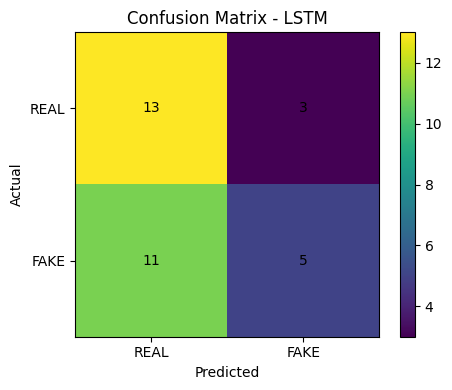

Confusion matrix saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix_LSTM.png


In [89]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["REAL", "FAKE"])
plt.yticks([0, 1], ["REAL", "FAKE"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

cm_path = os.path.join(GRAPH_DIR, f"confusion_matrix_{best_model_name}.png")
plt.savefig(cm_path)
plt.show()

print("Confusion matrix saved:", cm_path)

In [92]:
def classify_final_score(score):
    if score >= 0.55:
        return "FAKE"
    elif score <= 0.45:
        return "REAL"
    else:
        return "UNCERTAIN"


def get_verdict(predicted_label, score):
    if predicted_label == "FAKE":
        return "The video is likely fake."
    elif predicted_label == "REAL":
        return "The video is likely real."
    else:
        return "The model is not confident. Manual review is recommended."


def get_explanation(predicted_label, score):
    if predicted_label == "FAKE":
        return f"The final fake probability score is {score:.4f}, which is above the fake threshold."
    elif predicted_label == "REAL":
        return f"The final fake probability score is {score:.4f}, which is below the real threshold."
    else:
        return f"The final fake probability score is {score:.4f}, which lies between real and fake thresholds."


prediction_records = []

for i, row in test_df.reset_index(drop=True).iterrows():
    filename = row["filename"]
    true_label = row["label"]

    final_score = float(best_probs[i])
    predicted_label = classify_final_score(final_score)

    verdict = get_verdict(predicted_label, final_score)
    explanation = get_explanation(predicted_label, final_score)

    prediction_records.append({
        "filename": filename,
        "true_label": true_label,
        "best_model": best_model_name,
        "final_score": final_score,
        "predicted_label": predicted_label,
        "verdict": verdict,
        "explanation": explanation
    })

prediction_df = pd.DataFrame(prediction_records)

prediction_path = os.path.join(PRED_DIR, "best_model_final_predictions.csv")
prediction_df.to_csv(prediction_path, index=False)

print("Final prediction file saved:", prediction_path)
prediction_df.head(20)

Final prediction file saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/best_model_final_predictions.csv


,filename,true_label,best_model,final_score,predicted_label,verdict,explanation
0,esjdyghhog.mp4,FAKE,LSTM,0.494700,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4947, wh..."
1,msfssnmldu.mp4,FAKE,LSTM,0.287226,REAL,The video is likely real.,"The final fake probability score is 0.2872, wh..."
2,rmuxlgsedw.mp4,REAL,LSTM,0.433714,REAL,The video is likely real.,"The final fake probability score is 0.4337, wh..."
3,lnjkpdviqb.mp4,REAL,LSTM,0.418932,REAL,The video is likely real.,"The final fake probability score is 0.4189, wh..."
4,jawgcggquk.mp4,REAL,LSTM,0.499265,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4993, wh..."
5,qjvjkojjkl.mp4,FAKE,LSTM,0.491021,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4910, wh..."
6,gbgtzspdnv.mp4,FAKE,LSTM,0.396463,REAL,The video is likely real.,"The final fake probability score is 0.3965, wh..."
7,iocjgjemeb.mp4,FAKE,LSTM,0.507764,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.5078, wh..."
8,kqlvggiqee.mp4,REAL,LSTM,0.458403,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4584, wh..."
9,fzvpbrzssi.mp4,REAL,LSTM,0.358615,REAL,The video is likely real.,"The final fake probability score is 0.3586, wh..."


In [93]:
print(prediction_df["predicted_label"].value_counts())

uncertain_df = prediction_df[prediction_df["predicted_label"] == "UNCERTAIN"]
uncertain_path = os.path.join(UNCERTAIN_DIR, "uncertain_samples.csv")
uncertain_df.to_csv(uncertain_path, index=False)

print("Uncertain samples saved:", uncertain_path)

predicted_label
UNCERTAIN    19
REAL         10
FAKE          3
Name: count, dtype: int64
Uncertain samples saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/uncertain_samples/uncertain_samples.csv


In [115]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from IPython.display import Image, display

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")

os.makedirs(EXPLAIN_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(CSV_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(CSV_DIR, "test.csv"))

all_df = pd.concat([train_df, test_df]).reset_index(drop=True)

print("Train videos:", len(train_df))
print("Test videos:", len(test_df))
print("All videos:", len(all_df))

Train videos: 128
Test videos: 32
All videos: 160


In [116]:
frame_records = []

for _, row in all_df.iterrows():
    filename = row["filename"]
    video_id = Path(filename).stem
    target = int(row["target"])

    frame_folder = os.path.join(FRAMES_DIR, video_id)
    frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

    for frame_path in frame_paths:
        frame_records.append({
            "frame_path": str(frame_path),
            "target": target,
            "video_filename": filename
        })

frame_df = pd.DataFrame(frame_records)

print("Total frames found:", len(frame_df))
print(frame_df["target"].value_counts())
frame_df.head()

Total frames found: 2400
target
0    1200
1    1200
Name: count, dtype: int64


,frame_path,target,video_filename
0,/content/drive/MyDrive/Deepfake_Project/data/p...,0,ddtbarpcgo.mp4
1,/content/drive/MyDrive/Deepfake_Project/data/p...,0,ddtbarpcgo.mp4
2,/content/drive/MyDrive/Deepfake_Project/data/p...,0,ddtbarpcgo.mp4
3,/content/drive/MyDrive/Deepfake_Project/data/p...,0,ddtbarpcgo.mp4
4,/content/drive/MyDrive/Deepfake_Project/data/p...,0,ddtbarpcgo.mp4


In [117]:
train_frame_df, val_frame_df = train_test_split(
    frame_df,
    test_size=0.2,
    random_state=42,
    stratify=frame_df["target"]
)

print("Train frames:", len(train_frame_df))
print("Validation frames:", len(val_frame_df))

Train frames: 1920
Validation frames: 480


In [118]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_frame_df,
    x_col="frame_path",
    y_col="target",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_frame_df,
    x_col="frame_path",
    y_col="target",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1920 validated image filenames.
Found 480 validated image filenames.


In [119]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid", name="visual_output")(x)

visual_gradcam_model = Model(inputs, outputs)

visual_gradcam_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

visual_gradcam_model.summary()

Model: "functional_215"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ visual_output (Dense)           │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [120]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

visual_history = visual_gradcam_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

visual_gradcam_model.save(visual_model_path)

print("Visual Grad-CAM model saved:", visual_model_path)

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6167 - loss: 0.6917 - val_accuracy: 0.6896 - val_loss: 0.6009
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6505 - loss: 0.6601 - val_accuracy: 0.6750 - val_loss: 0.6044
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6562 - loss: 0.6603 - val_accuracy: 0.7083 - val_loss: 0.5941
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.6526 - loss: 0.6385 - val_accuracy: 0.6771 - val_loss: 0.6028
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.6568 - loss: 0.6314 - val_accuracy: 0.6604 - val_loss: 0.6076
Visual Grad-CAM model saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/visual_mobilenetv2_gradcam_model.keras


In [121]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras")

visual_gradcam_model = tf.keras.models.load_model(visual_model_path)

print("Visual model loaded successfully.")

Visual model loaded successfully.


In [ ]:
def get_mobilenet_base_model(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenet" in layer.name.lower():
            return layer
    raise ValueError("MobileNetV2 base model not found inside visual model.")


def make_gradcam_heatmap(img_array, full_model):
    base_model = get_mobilenet_base_model(full_model)

    
    last_conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.output
    )

    base_index = full_model.layers.index(base_model)

    classifier_input = tf.keras.Input(shape=base_model.output.shape[1:])
    x = classifier_input

    for layer in full_model.layers[base_index + 1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()


def save_gradcam_image(frame_path, output_path, model):
    img = image.load_img(frame_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(img_array, model)

    original_img = cv2.imread(frame_path)
    original_img = cv2.resize(original_img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    gradcam_img = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

    cv2.imwrite(output_path, gradcam_img)

    return output_path

Grad-CAM saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/esjdyghhog_gradcam_test.jpg


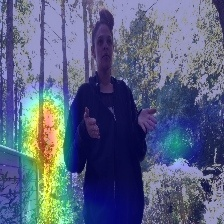

In [123]:
sample_row = test_df.iloc[0]

filename = sample_row["filename"]
video_id = Path(filename).stem

frame_folder = os.path.join(FRAMES_DIR, video_id)
frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

selected_frame = str(frame_paths[len(frame_paths) // 2])

output_path = os.path.join(EXPLAIN_DIR, f"{video_id}_gradcam_test.jpg")

save_gradcam_image(
    frame_path=selected_frame,
    output_path=output_path,
    model=visual_gradcam_model
)

print("Grad-CAM saved:", output_path)
display(Image(filename=output_path))

In [124]:
prediction_path = os.path.join(PRED_DIR, "best_model_final_predictions.csv")

prediction_df = pd.read_csv(prediction_path)

print("Loaded predictions:", len(prediction_df))
prediction_df.head()

Loaded predictions: 32


,filename,true_label,best_model,final_score,predicted_label,verdict,explanation
0,esjdyghhog.mp4,FAKE,LSTM,0.494700,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4947, wh..."
1,msfssnmldu.mp4,FAKE,LSTM,0.287226,REAL,The video is likely real.,"The final fake probability score is 0.2872, wh..."
2,rmuxlgsedw.mp4,REAL,LSTM,0.433714,REAL,The video is likely real.,"The final fake probability score is 0.4337, wh..."
3,lnjkpdviqb.mp4,REAL,LSTM,0.418932,REAL,The video is likely real.,"The final fake probability score is 0.4189, wh..."
4,jawgcggquk.mp4,REAL,LSTM,0.499265,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4993, wh..."


In [ ]:
gradcam_paths = []

for _, row in tqdm(prediction_df.iterrows(), total=len(prediction_df)):
    filename = row["filename"]
    video_id = Path(filename).stem

    frame_folder = os.path.join(FRAMES_DIR, video_id)
    frame_paths = sorted(list(Path(frame_folder).glob("*.jpg")))

    if len(frame_paths) == 0:
        gradcam_paths.append("")
        continue

    
    selected_frame = str(frame_paths[len(frame_paths) // 2])

    output_path = os.path.join(
        EXPLAIN_DIR,
        f"{video_id}_lstm_visual_gradcam.jpg"
    )

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=output_path,
            model=visual_gradcam_model
        )

        gradcam_paths.append(output_path)

    except Exception as e:
        print("Grad-CAM failed for:", filename)
        print("Error:", e)
        gradcam_paths.append("")

prediction_df["gradcam_image_path"] = gradcam_paths

final_lstm_gradcam_path = os.path.join(
    PRED_DIR,
    "lstm_final_predictions_with_gradcam.csv"
)

prediction_df.to_csv(final_lstm_gradcam_path, index=False)

print("Final LSTM prediction file with Grad-CAM saved:")
print(final_lstm_gradcam_path)

prediction_df.head()

100%|██████████| 32/32 [00:25<00:00,  1.25it/s]

Final LSTM prediction file with Grad-CAM saved:
/content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/lstm_final_predictions_with_gradcam.csv


,filename,true_label,best_model,final_score,predicted_label,verdict,explanation,gradcam_image_path
0,esjdyghhog.mp4,FAKE,LSTM,0.494700,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4947, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
1,msfssnmldu.mp4,FAKE,LSTM,0.287226,REAL,The video is likely real.,"The final fake probability score is 0.2872, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
2,rmuxlgsedw.mp4,REAL,LSTM,0.433714,REAL,The video is likely real.,"The final fake probability score is 0.4337, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
3,lnjkpdviqb.mp4,REAL,LSTM,0.418932,REAL,The video is likely real.,"The final fake probability score is 0.4189, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...
4,jawgcggquk.mp4,REAL,LSTM,0.499265,UNCERTAIN,The model is not confident. Manual review is r...,"The final fake probability score is 0.4993, wh...",/content/drive/MyDrive/Deepfake_Project/data/o...


Filename: esjdyghhog.mp4
True Label: FAKE
Predicted Label: UNCERTAIN
Final LSTM Score: 0.4947001338005066
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/esjdyghhog_lstm_visual_gradcam.jpg


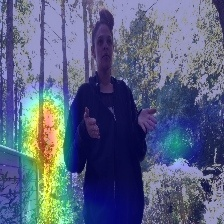

--------------------------------------------------------------------------------
Filename: msfssnmldu.mp4
True Label: FAKE
Predicted Label: REAL
Final LSTM Score: 0.2872264981269836
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/msfssnmldu_lstm_visual_gradcam.jpg


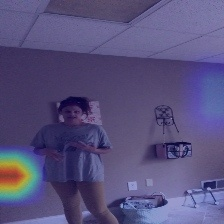

--------------------------------------------------------------------------------
Filename: rmuxlgsedw.mp4
True Label: REAL
Predicted Label: REAL
Final LSTM Score: 0.4337137043476105
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/rmuxlgsedw_lstm_visual_gradcam.jpg


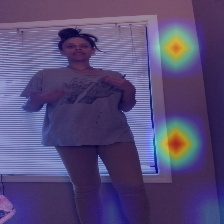

--------------------------------------------------------------------------------
Filename: lnjkpdviqb.mp4
True Label: REAL
Predicted Label: REAL
Final LSTM Score: 0.4189322292804718
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/lnjkpdviqb_lstm_visual_gradcam.jpg


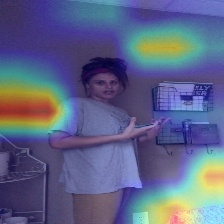

--------------------------------------------------------------------------------
Filename: jawgcggquk.mp4
True Label: REAL
Predicted Label: UNCERTAIN
Final LSTM Score: 0.4992647767066955
Grad-CAM: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/jawgcggquk_lstm_visual_gradcam.jpg


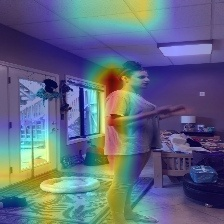

--------------------------------------------------------------------------------


In [126]:
sample_gradcams = prediction_df[prediction_df["gradcam_image_path"] != ""].head(5)

for _, row in sample_gradcams.iterrows():
    print("Filename:", row["filename"])
    print("True Label:", row["true_label"])
    print("Predicted Label:", row["predicted_label"])
    print("Final LSTM Score:", row["final_score"])
    print("Grad-CAM:", row["gradcam_image_path"])
    display(Image(filename=row["gradcam_image_path"]))
    print("-" * 80)

New video path set: /content/drive/MyDrive/my1.mp4


,filename,video_path,label,target,original
0,my1.mp4,/content/drive/MyDrive/my1.mp4,UNKNOWN,-1,None


Extracting frames for my1.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my1
Extracting audio for my1.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my1.wav
Extracting visual features for my1.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my1.mp4,0.045448,0.897333,0.211385,0.25758,0.230682,0.257641,0.082635,0.381627,0.063113,...,0.063697,0.528531,0.751797,1.085291,0.397981,1.141974,0.375926,0.42174,0.454807,0.213901


Extracting audio features for my1.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my1.mp4,-382.707764,130.854797,-18.479506,27.687174,-0.563039,1.198451,-11.071355,-7.697257,-9.34627,...,0.843645,0.75677,0.716468,0.687034,0.756703,0.668324,0.610633,0.627199,0.591461,0.526318


Transcribing audio for my1.mp4...
Transcript: おرßenึwardב


,transcript
filename,
my1.mp4,おرßenึwardב


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
Prediction score for my1.mp4: 0.5022
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5022, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my1_gradcam_new_video.jpg


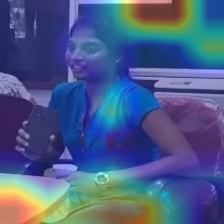

In [ ]:
NEW_VIDEO_FILENAME = "my1.mp4" 
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)


new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], 
    "target": [-1], 
    "original": [None]
})

display(new_video_df.head())


new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")


new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")


print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())


print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())


print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())


new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)



scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)


lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))


new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")


new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)


new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

 
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/trump.mp4


,filename,video_path,label,target,original
0,trump.mp4,/content/drive/MyDrive/trump.mp4,UNKNOWN,-1,None


Extracting frames for trump.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/trump
Extracting audio for trump.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/trump.wav
Extracting visual features for trump.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,trump.mp4,0.14634,0.022238,0.012528,0.020478,0.29137,0.401544,0.195107,0.014345,0.008432,...,0.099659,0.368318,0.14024,0.20313,0.685406,0.235435,0.178164,0.011099,1.58045,0.230606


Extracting audio features for trump.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,trump.mp4,-343.694,94.41687,-22.489487,13.169701,4.841062,-8.469874,-9.498224,-15.450096,-12.445945,...,0.849839,0.719237,0.783514,0.900826,0.756871,0.684957,0.799883,0.868905,0.877737,0.806473


Transcribing audio for trump.mp4...
Transcript:  oriented. Think of it. These people come from a crooked country, disgusting country, one of the worst countries in the world. Acknowledge to be one of the worst countries in a world. Some people say


,transcript
filename,
trump.mp4,oriented. Think of it. These people come from...


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Prediction score for trump.mp4: 0.4279
Predicted Label: REAL
Verdict: The video is likely real.
Explanation: The final fake probability score is 0.4279, which is below the real threshold.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/trump_gradcam_new_video.jpg


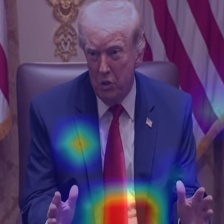

In [ ]:
NEW_VIDEO_FILENAME = "trump.mp4" 
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)


new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], 
    "target": [-1],
    "original": [None]
})

display(new_video_df.head())


new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")


new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")


print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())


print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())


print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())


new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)



scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)


lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))


new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")


new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)


new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")


    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/obama.mp4


,filename,video_path,label,target,original
0,obama.mp4,/content/drive/MyDrive/obama.mp4,UNKNOWN,-1,None


Extracting frames for obama.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/obama
Extracting audio for obama.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/obama.wav
Extracting visual features for obama.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,obama.mp4,1.118064,0.325018,0.023811,0.070571,0.2031,0.423698,0.029677,0.056942,0.063847,...,0.671186,2.097774,0.584096,0.361024,0.114145,0.1185,0.010316,0.008829,1.962282,0.077248


Extracting audio features for obama.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,obama.mp4,-393.06308,119.785973,14.451062,7.479139,-7.516681,8.868546,-7.820014,-22.314421,-15.420857,...,0.739394,0.834415,1.072566,1.112559,1.105549,1.135613,1.149362,1.016224,0.919525,0.944713


Transcribing audio for obama.mp4...
Transcript:  Or Ben Carson is in the sunken place or how about this simply President Trump is a total and complete dipshit Now you see I would never say these things At least not in a public address, but someone else would someone


,transcript
filename,
obama.mp4,Or Ben Carson is in the sunken place or how a...


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
Prediction score for obama.mp4: 0.4969
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.4969, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/obama_gradcam_new_video.jpg


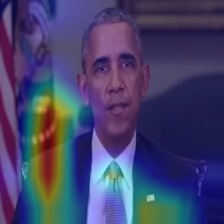

In [ ]:
NEW_VIDEO_FILENAME = "obama.mp4" 
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)


new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], 
    "target": [-1], 
    "original": [None]
})

display(new_video_df.head())


new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")


new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")


print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())


print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())


print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())


new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)


scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)


lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))


new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")


new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)


new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")


    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/Screen Recording 2026-04-21 142855.mp4


,filename,video_path,label,target,original
0,Screen Recording 2026-04-21 142855.mp4,/content/drive/MyDrive/Screen Recording 2026-0...,UNKNOWN,-1,None


Extracting frames for Screen Recording 2026-04-21 142855.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/Screen Recording 2026-04-21 142855
Extracting audio for Screen Recording 2026-04-21 142855.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/Screen Recording 2026-04-21 142855.wav
Extracting visual features for Screen Recording 2026-04-21 142855.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,Screen Recording 2026-04-21 142855.mp4,0.001956,0.193649,0.045042,0.144942,0.131035,0.781563,0.322187,0.208425,0.109172,...,0.395345,0.590236,0.351967,0.029721,0.043927,0.0,0.804201,0.415501,1.411822,0.009542


Extracting audio features for Screen Recording 2026-04-21 142855.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,Screen Recording 2026-04-21 142855.mp4,-579.881653,78.896828,-22.672224,12.139528,-9.890005,-14.435198,-15.997247,-24.505093,-14.389868,...,0.46082,0.450862,0.431364,0.497364,0.437276,0.459347,0.466366,0.467009,0.432612,0.44668


Transcribing audio for Screen Recording 2026-04-21 142855.mp4...
Transcript:  Our goal is to demystify and hold accountable those new technologies to avoid some of the mistakes of the past. And now for some introductory remarks.


,transcript
filename,
Screen Recording 2026-04-21 142855.mp4,Our goal is to demystify and hold accountable...


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Prediction score for Screen Recording 2026-04-21 142855.mp4: 0.4133
Predicted Label: REAL
Verdict: The video is likely real.
Explanation: The final fake probability score is 0.4133, which is below the real threshold.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/Screen Recording 2026-04-21 142855_gradcam_new_video.jpg


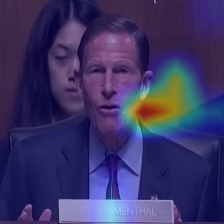

In [ ]:
NEW_VIDEO_FILENAME = "Screen Recording 2026-04-21 142855.mp4" 
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)


new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], 
    "target": [-1], 
    "original": [None]
})

display(new_video_df.head())


new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")


new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")


print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())


print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())


print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())


new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)


scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)


lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))


new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")


new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)


new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")


    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/my2.mp4


,filename,video_path,label,target,original
0,my2.mp4,/content/drive/MyDrive/my2.mp4,UNKNOWN,-1,None


Extracting frames for my2.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my2
Extracting audio for my2.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my2.wav
Extracting visual features for my2.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my2.mp4,0.059864,1.018467,0.142153,0.417605,0.009119,0.335589,0.052633,1.262263,0.19067,...,0.964407,1.342368,2.502553,0.008257,0.000403,0.919594,0.002039,0.017403,1.459862,0.044094


Extracting audio features for my2.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my2.mp4,-290.79071,115.540184,-7.419962,22.281208,-4.033728,4.035691,-11.912091,-6.527907,-12.423347,...,0.498168,0.488868,0.531286,0.584478,0.546848,0.688722,0.534834,0.519543,0.558753,0.579356


Transcribing audio for my2.mp4...
Transcript: 


,transcript
filename,
my2.mp4,


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Prediction score for my2.mp4: 0.5023
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5023, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my2_gradcam_new_video.jpg


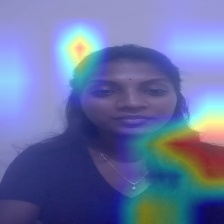

In [ ]:
NEW_VIDEO_FILENAME = "my2.mp4" 
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)


new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"],
    "target": [-1], 
    "original": [None]
})

display(new_video_df.head())


new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")


new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")


print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())


print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())


print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())

new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)


scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)


lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))


new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")


new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)


new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

   
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")

New video path set: /content/drive/MyDrive/my3.mp4


,filename,video_path,label,target,original
0,my3.mp4,/content/drive/MyDrive/my3.mp4,UNKNOWN,-1,None


Extracting frames for my3.mp4...
Frames extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/frames/my3
Extracting audio for my3.mp4...
Audio extracted to: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my3.wav
Extracting visual features for my3.mp4...


,filename,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,...,v_1270,v_1271,v_1272,v_1273,v_1274,v_1275,v_1276,v_1277,v_1278,v_1279
0,my3.mp4,0.0,0.287578,0.41102,0.488217,0.015382,0.075727,0.072154,1.500554,0.096928,...,0.010058,0.764158,1.874269,0.102094,0.01313,0.496447,0.00758,0.769445,0.091781,0.001622


Extracting audio features for my3.mp4...


,filename,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,a_8,...,a_230,a_231,a_232,a_233,a_234,a_235,a_236,a_237,a_238,a_239
0,my3.mp4,-541.058411,103.708641,41.705315,64.31604,16.04015,-2.786005,-6.509947,0.848891,6.020467,...,0.925812,0.850288,0.925537,0.956,0.880255,0.929733,0.931756,0.791987,0.622999,0.585146


Transcribing audio for my3.mp4...
Transcript: 


,transcript
filename,
my3.mp4,


Combined features shape for new video: (1, 2020)
Scaled and selected features shape for new video: (1, 500)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Prediction score for my3.mp4: 0.5009
Predicted Label: UNCERTAIN
Verdict: The model is not confident. Manual review is recommended.
Explanation: The final fake probability score is 0.5009, which lies between real and fake thresholds.
Grad-CAM image generated: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my3_gradcam_new_video.jpg


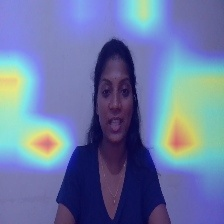

In [ ]:
NEW_VIDEO_FILENAME = "my3.mp4" 
NEW_VIDEO_PATH = os.path.join("/content/drive/MyDrive/", NEW_VIDEO_FILENAME)

print("New video path set:", NEW_VIDEO_PATH)


new_video_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "video_path": [NEW_VIDEO_PATH],
    "label": ["UNKNOWN"], 
    "target": [-1],
    "original": [None]
})

display(new_video_df.head())


new_video_id = Path(NEW_VIDEO_FILENAME).stem
new_frames_output_folder = os.path.join(FRAMES_DIR, new_video_id)

print(f"Extracting frames for {NEW_VIDEO_FILENAME}...")
frame_extracted = extract_frames(NEW_VIDEO_PATH, new_frames_output_folder, NUM_FRAMES)

if frame_extracted:
    print(f"Frames extracted to: {new_frames_output_folder}")
else:
    print(f"Failed to extract frames for {NEW_VIDEO_FILENAME}")


new_audio_path = os.path.join(AUDIO_DIR, f"{new_video_id}.wav")

print(f"Extracting audio for {NEW_VIDEO_FILENAME}...")
audio_extracted = extract_audio(NEW_VIDEO_PATH, new_audio_path)

if audio_extracted:
    print(f"Audio extracted to: {new_audio_path}")
else:
    print(f"Failed to extract audio for {NEW_VIDEO_FILENAME}")


print(f"Extracting visual features for {NEW_VIDEO_FILENAME}...")
new_visual_feature = extract_visual_feature(new_video_id)

new_visual_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_visual_feature):
    new_visual_records[0][f"v_{i}"] = value

new_visual_df = pd.DataFrame(new_visual_records)
display(new_visual_df.head())


print(f"Extracting audio features for {NEW_VIDEO_FILENAME}...")
new_audio_feature = extract_audio_feature(new_video_id)

new_audio_records = [{
    "filename": NEW_VIDEO_FILENAME
}]
for i, value in enumerate(new_audio_feature):
    new_audio_records[0][f"a_{i}"] = value

new_audio_df = pd.DataFrame(new_audio_records)
display(new_audio_df.head())


print(f"Transcribing audio for {NEW_VIDEO_FILENAME}...")
new_transcript = transcribe_audio(new_video_id)

new_text_df = pd.DataFrame({
    "filename": [NEW_VIDEO_FILENAME],
    "transcript": [new_transcript]
}).set_index("filename")

print("Transcript:", new_transcript)
display(new_text_df.head())


new_X_visual = new_visual_df[visual_cols].values
new_X_audio = new_audio_df[audio_cols].values
new_X_text = tfidf.transform([new_text_df.loc[NEW_VIDEO_FILENAME, "transcript"]]).toarray()

new_X = np.hstack([new_X_visual, new_X_audio, new_X_text])

print("Combined features shape for new video:", new_X.shape)


scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
selector = joblib.load(os.path.join(MODEL_DIR, "feature_selector.pkl"))

new_X_scaled = scaler.transform(new_X)
new_X_selected = selector.transform(new_X_scaled)

print("Scaled and selected features shape for new video:", new_X_selected.shape)


lstm_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_lstm_model.keras"))


new_X_lstm = new_X_selected.reshape(1, new_X_selected.shape[1], 1)

new_lstm_probs = lstm_model.predict(new_X_lstm).ravel()
new_final_score = float(new_lstm_probs[0])

print(f"Prediction score for {NEW_VIDEO_FILENAME}: {new_final_score:.4f}")


new_predicted_label = classify_final_score(new_final_score)
new_verdict = get_verdict(new_predicted_label, new_final_score)
new_explanation = get_explanation(new_predicted_label, new_final_score)

print("Predicted Label:", new_predicted_label)
print("Verdict:", new_verdict)
print("Explanation:", new_explanation)


new_frame_paths = sorted(list(Path(new_frames_output_folder).glob("*.jpg")))

if new_frame_paths:
    selected_frame = str(new_frame_paths[len(new_frame_paths) // 2])
    new_gradcam_output_path = os.path.join(EXPLAIN_DIR, f"{new_video_id}_gradcam_new_video.jpg")

   
    visual_gradcam_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "visual_mobilenetv2_gradcam_model.keras"))

    try:
        save_gradcam_image(
            frame_path=selected_frame,
            output_path=new_gradcam_output_path,
            model=visual_gradcam_model
        )
        print("Grad-CAM image generated:", new_gradcam_output_path)
        display(Image(filename=new_gradcam_output_path))
    except Exception as e:
        print(f"Failed to generate Grad-CAM for {NEW_VIDEO_FILENAME}: {e}")
else:
    print("No frames found to generate Grad-CAM.")